# Mise à disposition du jeu de données stroke_dataset via une API REST

## Description du dataset

Le jeu de données utilisé provient de Kaggle : [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset).  
Il contient des données de patients avec différentes caractéristiques médicales et sociales, ainsi que l'information si le patient a subi un accident vasculaire cérébral (AVC) ou non.

Télécharger les données et ajouter les dans un dossier data/.

Les colonnes des données sont :  
- `id` : Identifiant unique du patient  
- `gender` : Sexe  
- `age` : Âge  
- `hypertension` : Présence d'hypertension (0 ou 1)  
- `heart_disease` : Présence de maladie cardiaque (0 ou 1)  
- `ever_married` : Statut marital  
- `work_type` : Type d'emploi  
- `Residence_type` : Urbaine ou rurale  
- `avg_glucose_level` : Moyenne du taux de glucose  
- `bmi` : Indice de masse corporelle  
- `smoking_status` : Statut tabagique  
- `stroke` : Présence d'AVC (0 ou 1)

## Projet

Vous devez exposer les données patients du jeu de données via une API REST afin que les données soit utilisables par d'autres équipes (médecins, data science, étude, etc.).

Cette API REST sera développée avec FastAPI et les spécifications sont les suivantes :
| Méthode | Endpoint                                      | Fonctionnalité                                                                                                    |
| ------- | --------------------------------------------- | ----------------------------------------------------------------------------------------------------------------- |
| `GET`   | `/patients/{id}`                              | Récupère les détails d’un patient donné (via son identifiant unique)                                              |
| `GET`   | `/patients?stroke=1&gender=Female&max_age=60` | Renvoie les patients filtrés selon plusieurs critères : AVC (oui/non), genre, âge maximal                         |
| `GET`   | `/stats/`                                     | Fournit des statistiques agrégées sur les patients (ex. : nb total de patients, âge moyen, taux d’AVC, répartition hommes/femmes, etc.) |



---

## Quelques définitions


1. Qu’est-ce qu’une API REST ?

- API signifie Application Programming Interface (Interface de Programmation d’Application). C’est un ensemble de règles et de protocoles qui permettent à des logiciels de communiquer entre eux.
- REST signifie Representational State Transfer. C’est un style architectural pour concevoir des services web.
Il en existe d'autres mais REST est celui que vous rencontrerez le plus souvent.
- Vous avez utilisé une API REST via l'API Google Books.

- A quoi sert une API REST ?

    - Permet à différentes applications de communiquer facilement, même si elles sont écrites dans des langages différents.
    - Permet d’accéder à des services distants (ex : bases de données, services web) de manière standardisée.
    - Facilite la création d’applications modulaires et évolutives (front-end, back-end, mobile, etc.)

2. Principes clés d’une API REST

- a. Utilisation du protocole HTTP
Les échanges entre client et serveur utilisent des méthodes HTTP standard comme :

    - GET : pour récupérer des données
    - POST : pour envoyer ou créer des données
    - PUT : pour mettre à jour des données
    - DELETE : pour supprimer des données

- b. Accès aux ressources via des URLs

Chaque ressource (par exemple un livre, un utilisateur) est accessible via une URL unique.

Exemple fictif:
    https://api.example.com/books/123 pour accéder au livre d’identifiant 123.

- c. Stateless (sans état)

Le serveur ne conserve aucune information sur le client entre deux requêtes. Chaque requête doit contenir toutes les informations nécessaires.

- d. Représentations des données

Les données sont envoyées et reçues généralement en format JSON ou XML, qui sont faciles à lire et à manipuler.

- e. Utilisation de codes status HTTP

Chaque réponse du serveur est accompagnée d’un code HTTP indiquant le résultat de la requête. (cf [liste des codes](https://developer.mozilla.org/en-US/docs/Web/HTTP/Reference/Status))

## Outils utilisés
1. FastAPI

FastAPI est un framework Python moderne, rapide et très utilisé dans le milieu professionnel pour construire des API REST. 

Il permet :
- une définition simple des routes et des paramètres  
- La génération automatique de documentation interactive (Swagger UI)  
- FastAPI lit les requêtes entrantes, les traite avec ton code Python, et retourne une réponse HTTP (en JSON).

2. Uvicorn : exécute l'application FastAPI

- Uvicorn est un serveur ASGI (Asynchronous Server Gateway Interface) : c'est une interface standard pour gérer les requêtes de manière asynchrone et performante, notamment utile pour les applications modernes.
- Il attend les requêtes HTTP (par exemple depuis un navigateur), les transmet à FastAPI, et renvoie la réponse.
- Uvicorn permet à l'API de fonctionner : sans Uvicorn ou un autre serveur, FastAPI ne peut pas fonctionner.


3. Swagger UI : l’interface de doc et test interactive

- Swagger UI est généré automatiquement par FastAPI.
- C’est une interface web qui permet de :
    - Voir toutes les routes disponibles dans l'API
    - Tester les routes en envoyant des requêtes sans écrire de code (bouton try it out)
    - Voir les paramètres attendus et les formats de réponse
    
4. Résumé des interactions

- Tester la route de base de l'API grâce à la commande :
```bash
    poetry run fastapi dev stroke_api/main.py
```

--> Qu'est-ce qu'il se passe derrière cette commande ?

- Uvicorn démarre un serveur local
- FastAPI génère automatiquement une interface : Swagger UI, accessible sur http://127.0.0.1:8000/docs qui affiche toutes les routes définies dans le code python FastAPI
- Quand on clique sur "Try it out" dans Swagger UI, Swagger envoie une requête HTTP au serveur (ici Uvicorn)
- Le serveur (Uvicorn) la reçoit, l’envoie à FastAPI, qui traite et renvoie une réponse
- Swagger UI affiche la réponse de l’API (par ex : liste de patients)

---

Import des bibliothèques utiles au projet

In [31]:
import pandas as pd

## 1. Prétraitement des données / Data preprocessing

Les données réelles sont rarement prêtes à être utilisées directement. Elles peuvent contenir des erreurs, des valeurs manquantes, des doublons, des formats incohérents, ou ne pas être adaptées au modèle ou au système cible.

Le prétraitement consiste à nettoyer, structurer et transformer les données brutes avant de les exploiter dans un projet (modèle IA, API, visualisation, etc.).

Vous avez déjà prétraité des données, petit rappel des éléments sur lesquels travailler dans un prétraitment classique et les méthodes pandas qu'il est possible d'utiliser pour les différentes étapes (des exeples d'utilisation des méthodes pandas sont disponibles dans la doc) : 
- explorer les données pour identifier les types de données, valeurs manquantes, incohérence ([info](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.info.html), [dtypes](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dtypes.html))
- adapter les types si nécessaire ([astypes](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.astype.html))
- identifier les doublons et les supprimer s'il y en a ([duplicated](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.duplicated.html), [drop_duplicates](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop_duplicates.html))
- traiter les valeurs manquantes s'il y en a ([fillna](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html), [dropna](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html), [replace](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.replace.html))
- identifier les incohérences éventuelles (valeurs aberrantes/outliers) en vérifiant si les valeurs min, max, moyennes sont raisonnables (recherche internet si nécessaire) ([describe](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html)), et les traiter.
- Traiter les valeurs aberrantes si vous en détectez ([loc](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html) pour récupérer les lignes qui répondent à une certaine condition, cf exemple ci-dessous)


**Exemple df.loc :**

Récupérer toutes les lignes de df telles que la valeur de "nom de colonne" >= 0

```df_subset = df.loc[stroke_data_df['nom de colonne'] >= 0]```



---
### **TODO**
1.a. Prétraiter les données du dataset.


1.b. Documenter dans le README.md :
- Les étapes de prétraitement,
- Justification des choix concernant le traitement des valeurs manquantes (si besoin),
- Liste des valeurs raisonnables utilisées pour détecter les valeurs aberrantes, 
- Justification des choix pour traiter les valeurs aberrantes (si besoin).

2.a. Chercher des infos sur le format de fichier parquet et indiquer les sources consultées : 
- Différence principale avec le format csv ?
- Dans quels cas l'utiliser ? 
- Pourquoi c'est un format adapté aux gros volumes de données ?



2.b. Sauvegarder les données prétraiteées dans un fichier parquet ([to_parquet](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_parquet.html)).


## Prétraitement de données

In [32]:
#1. Chargement des données
df_original = pd.read_csv("data/healthcare-dataset-stroke-data.csv")
print(df_original)
df = df_original.copy()
# print(df)
print(df)


         id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban             228.69  36.6  former

In [33]:
# Vérification de la structure du jeu de données : colonnes, types, valeurs manquantes, statistiques de base.
df.info()
df.describe()
df.head()
print("valeurs manquantes : ")
df.isnull().sum()   
# J'ai des valeurs manquantes au niveau du BMI

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
valeurs manquantes : 


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [34]:
# Visualisation des valeurs aberrantes pour IBM 
df["bmi"].describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [35]:
# Afficher les patients avec BMI > 60 (éventuelles anomalies)	
df[df["bmi"] > 60]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
270,72911,Female,57.0,1,0,Yes,Private,Rural,129.54,60.9,smokes,0
358,66333,Male,52.0,0,0,Yes,Self-employed,Urban,78.40,64.8,never smoked,0
466,1307,Female,61.0,1,0,Yes,Private,Rural,170.05,60.2,smokes,0
544,545,Male,42.0,0,0,Yes,Private,Rural,210.48,71.9,never smoked,0
928,41097,Female,23.0,1,0,No,Private,Urban,70.03,78.0,smokes,0
1559,37759,Female,53.0,0,0,Yes,Private,Rural,72.63,66.8,Unknown,0
2128,56420,Male,17.0,1,0,No,Private,Rural,61.67,97.6,Unknown,0
2764,20292,Female,24.0,0,0,Yes,Private,Urban,85.55,63.3,never smoked,0
2840,65895,Female,52.0,0,0,Yes,Private,Urban,98.27,61.2,Unknown,0
3825,72784,Female,52.0,0,0,Yes,Private,Rural,118.46,61.6,smokes,0


## Comparaison des méthodes de remplacement Moyenne et Médiane

 Remplissage par MOYENNE
count    5110.000000
mean       28.893237
std         7.698018
min        10.300000
25%        23.800000
50%        28.400000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64

 Remplissage par MÉDIANE
count    5110.000000
mean       28.862035
std         7.699562
min        10.300000
25%        23.800000
50%        28.100000
75%        32.800000
max        97.600000
Name: bmi, dtype: float64


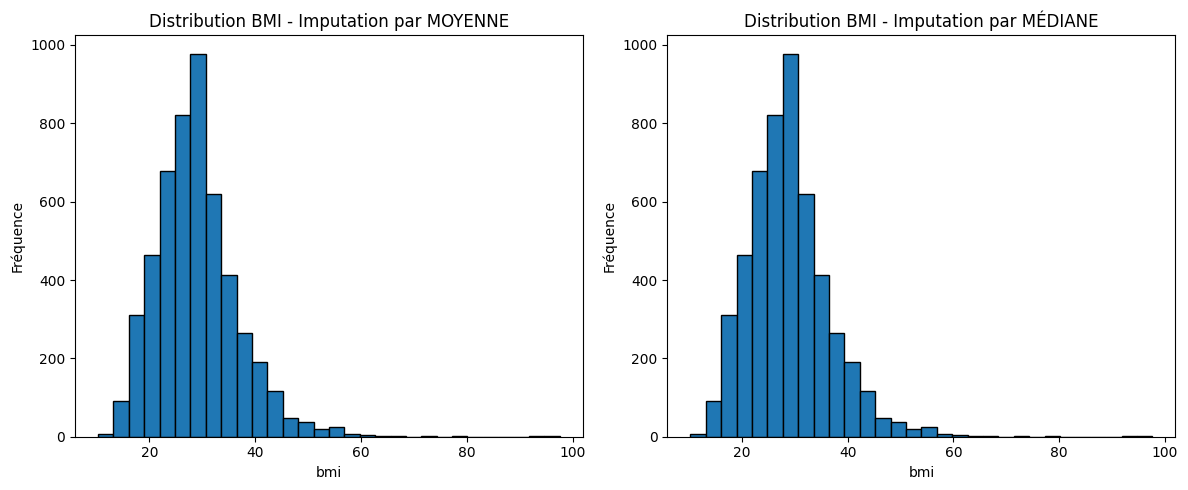

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Chargement des données
df = pd.read_csv("data/healthcare-dataset-stroke-data.csv")

# Copie du dataframe pour les deux méthodes
df_mean = df.copy()
df_median = df.copy()

# Remplir les NaN avec la moyenne
mean_bmi = df_mean["bmi"].mean()
df_mean["bmi"] = df_mean["bmi"].fillna(mean_bmi)

# Remplir les NaN avec la médiane
median_bmi = df_median["bmi"].median()
df_median["bmi"] = df_median["bmi"].fillna(median_bmi)

# Affichage des stats descriptives
print(" Remplissage par MOYENNE")
print(df_mean["bmi"].describe())

print("\n Remplissage par MÉDIANE")
print(df_median["bmi"].describe())

# Histogrammes comparatifs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_mean["bmi"], bins=30, edgecolor='black')
plt.title("Distribution BMI - Imputation par MOYENNE")
plt.xlabel("bmi")
plt.ylabel("Fréquence")

plt.subplot(1, 2, 2)
plt.hist(df_median["bmi"], bins=30, edgecolor='black')
plt.title("Distribution BMI - Imputation par MÉDIANE")
plt.xlabel("bmi")
plt.ylabel("Fréquence")

plt.tight_layout()
plt.show()


In [37]:
# # Remplir les NaN avec la médiane sur le dataframe original
mean_bmi = round(df["bmi"].mean(), 2)
df["bmi"] = df["bmi"].fillna(mean_bmi)
print(df["bmi"].dtype)
print(df["bmi"].isnull().sum())  # Afficher le nombre de NaN avant de remplir
df["bmi"] = df["bmi"].round(1) 
print(df)

float64
0
         id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban             228.69  36

In [38]:
# 1   gender             5110 non-null   object 
#  2   age                5110 non-null   float64
#  3   hypertension       5110 non-null   int64  
#  4   heart_disease      5110 non-null   int64  
#  5   ever_married       5110 non-null   object 
#  6   work_type          5110 non-null   object 
#  7   Residence_type     5110 non-null   object 
#  8   avg_glucose_level  5110 non-null   float64
#  9   bmi                4909 non-null   float64
#  10  smoking_status     5110 non-null   object 
#  11  stroke       


### Vérification des valeurs aberrantes pour la collonne âge


In [39]:
# Vérification des valeurs aberrantes pour la collonne âge
df.groupby('age')

df_sorted = df.sort_values(by='age')
print(df_sorted)

         id  gender    age  hypertension  heart_disease ever_married  \
1614  47350  Female   0.08             0              0           No   
3295  29955    Male   0.08             0              0           No   
3618  22877    Male   0.16             0              0           No   
3968  41500    Male   0.16             0              0           No   
4021   8247    Male   0.16             0              0           No   
...     ...     ...    ...           ...            ...          ...   
56    38829  Female  82.00             0              0          Yes   
4094  25510    Male  82.00             0              0          Yes   
4088  27705  Female  82.00             0              1          Yes   
4164  40163  Female  82.00             1              0          Yes   
23    64778    Male  82.00             0              1          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
1614       children          Urban             139.67  

In [42]:
# Regrouper les âges en tranches.

def age_group(age):
    if age < 2 :
        return "Nourrisson"
    elif age < 13:
        return "Enfant"
    elif age < 18:
        return "Adolescent"
    elif age < 60:
        return "Adulte"
    else:
        return "Senior"

df["age_grouped"] = df["age"].apply(age_group)
     


In [ ]:
print(df.sort_values(by=['age']))
print(df.columns)

         id  gender         age  hypertension  heart_disease ever_married  \
2554  72369  Female  Adolescent             0              0           No   
3728  54816  Female  Adolescent             0              0           No   
3734  51852  Female  Adolescent             0              0           No   
3744  43734    Male  Adolescent             0              0           No   
3749  70230  Female  Adolescent             0              0           No   
...     ...     ...         ...           ...            ...          ...   
3417  72354  Female      Senior             1              0          Yes   
1117   9415  Female      Senior             0              0          Yes   
1118  30989  Female      Senior             0              0          Yes   
3342  68193    Male      Senior             0              0          Yes   
0      9046    Male      Senior             0              1          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_statu

In [43]:
# Grouper par 'age' et 'smoking_status'
grouped = df.groupby(['age_grouped', 'smoking_status'])

# Afficher les combinaisons uniques de 'age' et 'smoking_status'
print(grouped.size())  # Affiche le nombre de valeurs dans chaque groupe

print(df.groupby(['smoking_status']).size())

age_grouped  smoking_status 
Adolescent   Unknown             135
             formerly smoked      15
             never smoked        111
             smokes                7
Adulte       Unknown             602
             formerly smoked     472
             never smoked       1215
             smokes              589
Enfant       Unknown             427
             formerly smoked      10
             never smoked         29
             smokes                2
Nourrisson   Unknown             120
Senior       Unknown             260
             formerly smoked     388
             never smoked        537
             smokes              191
dtype: int64
smoking_status
Unknown            1544
formerly smoked     885
never smoked       1892
smokes              789
dtype: int64


### Remplacement des valeurs de la colonne 'smoking_status' pour les Nourrisson passant de 'Unknown' en 'Never smoked' 


In [47]:
df.loc[(df['age_grouped'] == 'Nourrisson') & (df['smoking_status'] == 'Unknown'), 'smoking_status'] = 'Never smoked'


In [48]:
# Vérification
# Grouper par 'age' et 'smoking_status'
grouped = df.groupby(['age_grouped', 'smoking_status'])

# Afficher les combinaisons uniques de 'age' et 'smoking_status'
print(grouped.size())  # Affiche le nombre de valeurs dans chaque groupe

print(df.groupby(['smoking_status']).size())

age_grouped  smoking_status 
Adolescent   Unknown             135
             formerly smoked      15
             never smoked        111
             smokes                7
Adulte       Unknown             602
             formerly smoked     472
             never smoked       1215
             smokes              589
Enfant       Unknown             427
             formerly smoked      10
             never smoked         29
             smokes                2
Nourrisson   Never smoked        120
Senior       Unknown             260
             formerly smoked     388
             never smoked        537
             smokes              191
dtype: int64
smoking_status
Never smoked        120
Unknown            1424
formerly smoked     885
never smoked       1892
smokes              789
dtype: int64


### Visualisation des valeurs aberrantes par rapport aux emplois par tranche d'age :

In [49]:
# Grouper par 'age' et 'smoking_status'
grouped = df.groupby(['age_grouped', 'work_type'])

# Afficher les combinaisons uniques de 'age' et 'smoking_status'
print(grouped.size())  # Affiche le nombre de valeurs dans chaque groupe

print(df.groupby(['work_type']).size())

age_grouped  work_type    
Adolescent   Govt_job            6
             Never_worked       17
             Private           133
             Self-employed      11
             children          101
Adulte       Govt_job          457
             Never_worked        5
             Private          2068
             Self-employed     348
Enfant       Private             1
             Self-employed       1
             children          466
Nourrisson   children          120
Senior       Govt_job          194
             Private           723
             Self-employed     459
dtype: int64
work_type
Govt_job          657
Never_worked       22
Private          2925
Self-employed     819
children          687
dtype: int64


### Visualisation des valeurs aberrantes au niveau des personnes mariées par tranche d'age : aucune modification cela me semble cohérent selon les tranches d'âges.

In [50]:
groupe= df.groupby(['age_grouped', 'ever_married'])

print(groupe.size())

age_grouped  ever_married
Adolescent   No               268
Adulte       No               794
             Yes             2084
Enfant       No               468
Nourrisson   No               120
Senior       No               107
             Yes             1269
dtype: int64


### Visualisation des valeurs aberrantes sur le niveau moyen de glucose (avg_glucose_level) par tranches d'âges:

In [51]:
# Taux minimum de glucose par tranche d’âge
print(df.groupby("age_grouped")["avg_glucose_level"].min())


age_grouped
Adolescent    55.39
Adulte        55.12
Enfant        55.34
Nourrisson    55.51
Senior        55.23
Name: avg_glucose_level, dtype: float64


In [52]:
# Taux maximum de glucose par tranche d’âge
print(df.groupby("age_grouped")["avg_glucose_level"].max())

age_grouped
Adolescent    233.71
Adulte        267.76
Enfant        213.87
Nourrisson    199.83
Senior        271.74
Name: avg_glucose_level, dtype: float64



### Sauvegarder les données prétraiteées dans un fichier parquet ([to_parquet](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_parquet.html)).


In [53]:
df.to_parquet(path="data/hearth_data.parquet", index=False)

-----
## Développement de l'API

A présent que les données sont propres, on peut débuter la création de l'API.

Pour cela, vous allez avoir besoin de quelques fonctions permettant de filtrer les données.

Vous allez les définir ci-dessous, ce qui vous permettra de les tester puis les fonctions seront reportées dans le fichier filters.py.

## Route `/patients/`
- Cette route retourne une liste filtrée de patients
- On souhaite pouvoir filtrer par `gender`, `stroke` ou `max_age`

L'objectif est ici de définir une fonction python qui prend en entrée les paramètres optionnels : _gender_, *stroke*, *max_age* et qui renvoie un dictionnaire filtré des données.

On décompose la rédaction de cette fonction en plusieurs étapes. 

Dans un premier temps, écrire et tester les filtres que l'on souhaite appliquer sur les données (utiliser [loc](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.loc.html))

In [55]:
data_hearth = pd.read_parquet("data/hearth_data.parquet")
print(data_hearth[data_hearth['age_grouped']=='Nourrisson'])

         id  gender   age  hypertension  heart_disease ever_married work_type  \
162   69768  Female  1.32             0              0           No  children   
363    7559  Female  0.64             0              0           No  children   
376   22706  Female  0.88             0              0           No  children   
562   45238  Female  1.80             0              0           No  children   
564   61511  Female  0.32             0              0           No  children   
...     ...     ...   ...           ...            ...          ...       ...   
4934  32147    Male  1.32             0              0           No  children   
5032  67426  Female  1.24             0              0           No  children   
5079  42709    Male  1.72             0              0           No  children   
5089  56714  Female  0.72             0              0           No  children   
5095  68598    Male  1.08             0              0           No  children   

     Residence_type  avg_gl

In [ ]:
# Filtrer le dataframe pour ne garder que les patients pour lesquels "stroke=1"
def patients_stroke(int):

    data = data_hearth.loc[data_hearth['stroke']== int]
    return data

stroke_positif =  patients_stroke(1)
print(stroke_positif)

        id  gender   age  hypertension  heart_disease ever_married  \
0     9046    Male  67.0             0              1          Yes   
1    51676  Female  61.0             0              0          Yes   
2    31112    Male  80.0             0              1          Yes   
3    60182  Female  49.0             0              0          Yes   
4     1665  Female  79.0             1              0          Yes   
..     ...     ...   ...           ...            ...          ...   
244  17739    Male  57.0             0              0          Yes   
245  49669  Female  14.0             0              0           No   
246  27153  Female  75.0             0              0          Yes   
247  34060    Male  71.0             1              0          Yes   
248  43424  Female  78.0             0              0          Yes   

         work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0          Private          Urban             228.69  36.6  formerly smoked   
1

In [63]:
# Filtrer les données pour ne garder que les patients pour lesquels "gender="male"
gender_male = data_hearth.loc[data_hearth['gender'].str.lower() == 'male']
print(gender_male)

         id gender   age  hypertension  heart_disease ever_married  \
0      9046   Male  67.0             0              1          Yes   
2     31112   Male  80.0             0              1          Yes   
5     56669   Male  81.0             0              0          Yes   
6     53882   Male  74.0             1              1          Yes   
13     8213   Male  78.0             0              1          Yes   
...     ...    ...   ...           ...            ...          ...   
5097  64520   Male  68.0             0              0          Yes   
5098    579   Male   9.0             0              0           No   
5099   7293   Male  40.0             0              0          Yes   
5100  68398   Male  82.0             1              0          Yes   
5108  37544   Male  51.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban             228.69  36.6  formerly smoked   

In [ ]:
# Filtrer les données pour ne garder que les patients tels que "age <= max_age"
print(data_hearth["age"].dtype)
data_age = data_hearth.loc[data_hearth['age'] <= 8]
print(data_age)

float64
         id  gender   age  hypertension  heart_disease ever_married work_type  \
162   69768  Female  1.32             0              0           No  children   
249   30669    Male  3.00             0              0           No  children   
251   16523  Female  8.00             0              0           No   Private   
282   33759  Female  3.00             0              0           No  children   
291   11014    Male  4.00             0              0           No  children   
...     ...     ...   ...           ...            ...          ...       ...   
5070  62425  Female  5.00             0              0           No  children   
5078  27446  Female  8.00             0              0           No  children   
5079  42709    Male  1.72             0              0           No  children   
5089  56714  Female  0.72             0              0           No  children   
5095  68598    Male  1.08             0              0           No  children   

     Residence_type

Appliquer successivement les 3 filtres au sein d'une fonction qui prend en entrée le dataframe, _stroke_, _gender_, _max_age_ et qui renvoie une liste de dictionnaire de patients (utiliser la méthode pandas [to_dict](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_dict.html)).

Exemple
```
[{'id': 9046,
  'gender': 'Male',
  'age': 67.0,
  ...
  'smoking_status': 'formerly smoked',
  'stroke': 1},
 {'id': 31112,
  'gender': 'Male',
  'age': 80.0,
  ...
  'smoking_status': 'formerly smoked',
  'stroke': 1}]
  ```

In [94]:
def filter_patient(df, max_age, gender, stroke) :


   data = df.loc[
      (df['age'] <= max_age) & 
      (df['stroke']== stroke) & 
      (df['gender'].str.lower() == gender)
      ]
    
   return data.to_dict('records')
 
print(filter_patient(data_hearth,'male', 1))

TypeError: filter_patient() missing 1 required positional argument: 'stroke'

A présent on souhaite ajouter des informations sur les types des paramètres et valeurs de retour de la fonction pour faciliter sa compréhension et son utilisation, ce qu’on appelle l’annotation de type (type hinting).

Cette pratique facilite la lecture et la maintenance du code.

Quels changements pour la fonction ?

A la suite de chaque paramètre, on ajoute le type attendu pour le paramètre. À la suite des paramètres on ajoute le type de ce que qui est retourné par la fonction, dans l'exemple ici : 

```def filter_patient(stroke_data_df: pd.DataFrame, gender: str, etc) -> list[dict]```

Ajouter les types dans la définition de la fonction.

Tester la fonction en ne mettant pas de valeur pour *max_age*.

Que se passe-t-il ?

Il y'a une erreur: la fonction attend un argument 'stroke' car elle attend l'argument 'stroke' en dernier, il y'a un décalage. Mais c'est bien l'argument max_age qu'il manque. 

In [ ]:
def filter_patient(df :  pd.DataFrame, max_age : float, gender : str, stroke: int) -> dict:
   """
   Filtre les patients selon l'âge maximal, le genre et l'état AVC.

   Cette fonction sélectionne les patients dans un DataFrame qui répondent
   aux critères suivants :
    - Âge inférieur ou égal à `max_age`
    - Sexe égal à `gender` (insensible à la casse)
    - AVC (`stroke`) égal à 0 ou 1

   Parameters
   ----------
   df : pd.DataFrame
     Le DataFrame contenant les données des patients.
   max_age : float
     L'âge maximal des patients à inclure dans le filtre.
   gender : str
     Le sexe du patient à filtrer (ex. : 'male' ou 'female').
     La comparaison est insensible à la casse.
   stroke : int
     1 pour sélectionner uniquement les patients ayant eu un AVC,
     0 pour ceux qui n’en ont pas eu.

   Returns
   -------
    dict
     Un dictionnaire de la forme `list[dict]` représentant les enregistrements filtrés.
     Chaque dictionnaire correspond à une ligne (patient).

   Example
   -------
   >>> filter_patient(data_hearth, 60, 'male', 1)
   [{'id': ..., 'age': ..., 'gender': 'Male', 'stroke': 1, ...}, ...]
   """


   data = df.loc[
      (df['age'] <= max_age) & 
      (df['stroke']== stroke) & 
      (df['gender'].str.lower() == gender)
      ]
    
   return data.to_dict('records')
 
print(filter_patient(data_hearth, 60,'male', 1))

Dans la fonction écrite ci-dessus, chaque paramètre est obligatoire. 

On souhaite pouvoir filtrer les patients sur 0, 1 ou 2 des paramètres de la fonction (filtrer seulement sur *max_age*  mais ne pas appliquer de filtres sur _gender_ et _stroke_ par exemple).

On peut rendre optionnel les paramètres d'un fonction en choisissant une valeur par défault. Si on utilise la fonction en n'utilisant pas ces paramètres alors la valeur par défault est utilisé.

Copier coller votre fonction ci-dessous et ajouter en paramètre : `max_age=None`

et ajouter la condition suivante **avant le filtre** sur `max_age` : 

```if max_age is not None : ``` 

Si la fonction _filter_patient_ est appelée sans argument *max_age*, alors le filtre sur *max_age* n'est pas appliqué. 

Il est tout à fait possible de définir une valeur par défault par exemple 30 ans : dans ce cas si la fonction est appelée sans argument *max_age*, alors par défault on filtre les patients ayant moins de 30 ans.

**ATTENTION :** Les paramètres optionnels doivent toujours être à la fin de la liste de paramètres.

In [122]:
# fonction filter_patient paramètre max_age optionnel
def filter_patient(df :  pd.DataFrame, max_age : float = None, gender : str = None, stroke: int = None) -> dict:
   """
   Filtre les patients selon l'âge maximal, le genre et l'état AVC.

   Cette fonction sélectionne les patients dans un DataFrame qui répondent
   aux critères suivants :
    - Âge inférieur ou égal à `max_age`
    - Sexe égal à `gender` (insensible à la casse)
    - AVC (`stroke`) égal à 0 ou 1

   Parameters
   ----------
   df : pd.DataFrame
     Le DataFrame contenant les données des patients.
   max_age : float
     L'âge maximal des patients à inclure dans le filtre.
   gender : str
     Le sexe du patient à filtrer (ex. : 'male' ou 'female').
     La comparaison est insensible à la casse.
   stroke : int
     1 pour sélectionner uniquement les patients ayant eu un AVC,
     0 pour ceux qui n’en ont pas eu.

   Returns
   -------
    dict
     Un dictionnaire de la forme `list[dict]` représentant les enregistrements filtrés.
     Chaque dictionnaire correspond à une ligne (patient).

   Example
   -------
   >>> filter_patient(data_hearth, 60, 'male', 1)
   [{'id': ..., 'age': ..., 'gender': 'Male', 'stroke': 1, ...}, ...]
   """


   data = df.copy()
   if max_age is not None:
      data= data[data['age'] <= max_age ]
   if stroke is not None:
      data = data[data['stroke']== stroke]
   if gender is not None: 
      data = data[data['gender'].str.lower() == gender]
      
    
   return data.to_dict('records')
 


In [123]:
# test fonction sans argument max_age
filtered_data = filter_patient(data_hearth, None, None, 1)

print(filtered_data)

[{'id': 9046, 'gender': 'Male', 'age': 67.0, 'hypertension': 0, 'heart_disease': 1, 'ever_married': 'Yes', 'work_type': 'Private', 'Residence_type': 'Urban', 'avg_glucose_level': 228.69, 'bmi': 36.6, 'smoking_status': 'formerly smoked', 'stroke': 1, 'age_grouped': 'Senior'}, {'id': 51676, 'gender': 'Female', 'age': 61.0, 'hypertension': 0, 'heart_disease': 0, 'ever_married': 'Yes', 'work_type': 'Self-employed', 'Residence_type': 'Rural', 'avg_glucose_level': 202.21, 'bmi': 28.9, 'smoking_status': 'never smoked', 'stroke': 1, 'age_grouped': 'Senior'}, {'id': 31112, 'gender': 'Male', 'age': 80.0, 'hypertension': 0, 'heart_disease': 1, 'ever_married': 'Yes', 'work_type': 'Private', 'Residence_type': 'Rural', 'avg_glucose_level': 105.92, 'bmi': 32.5, 'smoking_status': 'never smoked', 'stroke': 1, 'age_grouped': 'Senior'}, {'id': 60182, 'gender': 'Female', 'age': 49.0, 'hypertension': 0, 'heart_disease': 0, 'ever_married': 'Yes', 'work_type': 'Private', 'Residence_type': 'Urban', 'avg_gluco

Ajouter des valeurs par défault et les conditions pour chaque filtre.

Pour les types, on indique qu'il s'agit de paramètres optionels en utilisant le module python _typing_

```
from typing import Optional
def filter_patient(stroke_data_df: pd.DataFrame, gender: Optional[str] = None,etc)
```

Adapter les types en utilisant ce modèle.

In [126]:
# fonction avec ajout de paramètres par défault et de type
from typing import Optional

# fonction filter_patient paramètre max_age optionnel
def filter_patient(df :  pd.DataFrame, max_age : Optional[float] = None, gender : Optional[str] = None, stroke: Optional[int] = None) -> dict:
   """
   Filtre les patients selon l'âge maximal, le genre et l'état AVC.

   Cette fonction sélectionne les patients dans un DataFrame qui répondent
   aux critères suivants :
    - Âge inférieur ou égal à `max_age`
    - Sexe égal à `gender` (insensible à la casse)
    - AVC (`stroke`) égal à 0 ou 1

   Parameters
   ----------
   df : pd.DataFrame
     Le DataFrame contenant les données des patients.
   max_age : float
     L'âge maximal des patients à inclure dans le filtre.
   gender : str
     Le sexe du patient à filtrer (ex. : 'male' ou 'female').
     La comparaison est insensible à la casse.
   stroke : int
     1 pour sélectionner uniquement les patients ayant eu un AVC,
     0 pour ceux qui n’en ont pas eu.

   Returns
   -------
    dict
     Un dictionnaire de la forme `list[dict]` représentant les enregistrements filtrés.
     Chaque dictionnaire correspond à une ligne (patient).

   Example
   -------
   >>> filter_patient(data_hearth, 60, 'male', 1)
   [{'id': ..., 'age': ..., 'gender': 'Male', 'stroke': 1, ...}, ...]
   """


   data = df.copy()
   if max_age is not None:
      data= data[data['age'] <= max_age ]
   if stroke is not None:
      data = data[data['stroke']== stroke]
   if gender is not None: 
      data = data[data['gender'].str.lower() == gender]

   return data.to_dict('records')

Tester la fonction sans argument pour les filtres, elle doit donc renvoyer le dataframe non filtré.

In [135]:
# test fonction sans argument pour les filtres
filtered_data = filter_patient(data_hearth,None,'male', None)

print(filtered_data)

[{'id': 9046, 'gender': 'Male', 'age': 67.0, 'hypertension': 0, 'heart_disease': 1, 'ever_married': 'Yes', 'work_type': 'Private', 'Residence_type': 'Urban', 'avg_glucose_level': 228.69, 'bmi': 36.6, 'smoking_status': 'formerly smoked', 'stroke': 1, 'age_grouped': 'Senior'}, {'id': 31112, 'gender': 'Male', 'age': 80.0, 'hypertension': 0, 'heart_disease': 1, 'ever_married': 'Yes', 'work_type': 'Private', 'Residence_type': 'Rural', 'avg_glucose_level': 105.92, 'bmi': 32.5, 'smoking_status': 'never smoked', 'stroke': 1, 'age_grouped': 'Senior'}, {'id': 56669, 'gender': 'Male', 'age': 81.0, 'hypertension': 0, 'heart_disease': 0, 'ever_married': 'Yes', 'work_type': 'Private', 'Residence_type': 'Urban', 'avg_glucose_level': 186.21, 'bmi': 29.0, 'smoking_status': 'formerly smoked', 'stroke': 1, 'age_grouped': 'Senior'}, {'id': 53882, 'gender': 'Male', 'age': 74.0, 'hypertension': 1, 'heart_disease': 1, 'ever_married': 'Yes', 'work_type': 'Private', 'Residence_type': 'Rural', 'avg_glucose_leve

Cette fonction va être utilisée dans la définition de l'API pour créer une route qui permette d'accéder à des données filtrées sur les patients.

Dans le fichier de définition de l'API, toutes les fonctions vont travailler sur les données du fichier. 

Pour alléger les fonctions on va donc utiliser une **variable globale** pour les données et supprimer le paramètre `df` de la fonction.

On lit les données en début de fichier puis on travaille au sein des fonctions sur une copie du dataframe de données.


**En résumé les modifications à faire sont :**


- Supprimer le paramètre df de la fonction,
- Ajouter en début de fonction :  
```df = stroke_data_df.copy()```

1. Dans le fichier filters.py, il suffit d'ajouter : 
- lecture du fichier de données prétraitée dans la variable *df* en début de fichier (utiliser pandas),
- @app.get("/patients/") pour définir le route,
puis la fonction.

2. Dans le fichier api.py: appeler la fonction dans la route correspondante.

Tester la route avec 

```poetry run fastapi dev stroke_api/main.py```

http://127.0.0.1:8000/docs : utiliser la fonctionnalité Try it out pour tester la route.

In [ ]:
# Déclaration variable comportant DataFrame 
stroke_data_df = df

# fonction filter_patient paramètre max_age optionnel
def filter_patient(df :  pd.DataFrame, max_age : Optional[float] = None, gender : Optional[str] = None, stroke: Optional[int] = None) -> dict:
   """
   Filtre les patients selon l'âge maximal, le genre et l'état AVC.

   Cette fonction sélectionne les patients dans un DataFrame qui répondent
   aux critères suivants :
    - Âge inférieur ou égal à `max_age`
    - Sexe égal à `gender` (insensible à la casse)
    - AVC (`stroke`) égal à 0 ou 1

   Parameters
   ----------
   df : pd.DataFrame
     Le DataFrame contenant les données des patients.
   max_age : float
     L'âge maximal des patients à inclure dans le filtre.
   gender : str
     Le sexe du patient à filtrer (ex. : 'male' ou 'female').
     La comparaison est insensible à la casse.
   stroke : int
     1 pour sélectionner uniquement les patients ayant eu un AVC,
     0 pour ceux qui n’en ont pas eu.

   Returns
   -------
    dict
     Un dictionnaire de la forme `list[dict]` représentant les enregistrements filtrés.
     Chaque dictionnaire correspond à une ligne (patient).

   Example
   -------
   >>> filter_patient(data_hearth, 60, 'male', 1)
   [{'id': ..., 'age': ..., 'gender': 'Male', 'stroke': 1, ...}, ...]
   """

   df = stroke_data_df.copy()

   if max_age is not None:
      df= df[df['age'] <= max_age ]
   if stroke is not None:
      df = df[df['stroke']== stroke]
   if gender is not None: 
      df = df[df['gender'].str.lower() == gender]

   return df.to_dict('records')

In [ ]:
# test fonction sans argument pour les filtres
filtered_data = filter_patient(data_hearth,None,'male', None)

print(filtered_data)

---
## Autres routes

De la même manière, créer les fonctions appropriées pour la création de :
- la route `/patients/{id}` : Récupère les détails d’un patient donné (via son identifiant unique) 

- la route `/stats/` : Fournit des statistiques agrégées sur les patients (ex. : nb total de patients, âge moyen, taux d’AVC, répartition hommes/femmes).

- Lister les tâches à faire sous forme d'issue github : travailler sur une branche différentes pour l'ajout de chacune des routes.